In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Apr 26 14:23:30 2022

@author: mfbpe
"""
 
import os, numpy as np,  mne, os.path as op
from mne.channels import make_standard_montage
from glob import glob
from mne.minimum_norm import make_inverse_operator, apply_inverse
from mne.datasets import eegbci, sample, fetch_fsaverage
from eeg_function import drop_trials

# Download fsaverage files
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)

# The files live in:
subject = 'fsaverage'
trans = 'fsaverage'  # MNE has a built-in fsaverage transformation
src = op.join(fs_dir, 'bem', 'fsaverage-ico-5-src.fif')
bem = op.join(fs_dir, 'bem', 'fsaverage-5120-5120-5120-bem-sol.fif')


# Set the derivatives directory path
root_derivatives = 'C:/Users/mfbpe/Desktop/DATA/2025_Valuation/derivatives/'
os.chdir(root_derivatives)

all_files_path = sorted(glob(f"*raw.fif"), key=len)
  



0 files missing from root.txt in C:\Users\mfbpe\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage


In [2]:
raw = mne.io.read_raw_fif(all_files_path[0], preload=True)


raw.set_eeg_reference(projection=True)  # needed for inverse modeling


Opening raw data file sub-1_raw.fif...
    Range : 0 ... 1927679 =      0.000 ...  3764.998 secs
Ready.
Reading 0 ... 1927679  =      0.000 ...  3764.998 secs...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


<Raw | sub-1_raw.fif, 73 x 1927680 (3765.0 s), ~1.05 GiB, data loaded>

In [3]:
%matplotlib qt
# Check that the locations of EEG electrodes is correct with respect to MRI
mne.viz.plot_alignment(
    raw.info, src=src, eeg=['original', 'projected'], trans=trans,
    show_axes=True, mri_fiducials=True, dig='fiducials')


Reading C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage\bem\fsaverage-ico-5-src.fif...
Using pyvistaqt 3d backend.
Using outer_skin.surf for head surface.
Channel types::	eeg: 64
Projecting sensors to the head surface


### Setup source space and compute forward



In [ ]:
fwd = mne.make_forward_solution(raw.info, trans=trans, src=src,
                                bem=bem, eeg=True, mindist=5.0, n_jobs=-1)

Source space          : C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage\bem\fsaverage-ico-5-src.fif
MRI -> head transform : c:\Program Files\Anaconda3\envs\eeg\lib\site-packages\mne\data\fsaverage\fsaverage-trans.fif
Measurement data      : instance of Info
Conductor model   : C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage\bem\fsaverage-5120-5120-5120-bem-sol.fif
Accurate field computations
Do computations in head coordinates
Free source orientations

Reading C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage\bem\fsaverage-ico-5-src.fif...
Read 2 source spaces a total of 20484 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.999994 0.003552 0.000202      -1.76 mm
    -0.003558 0.998389 0.056626      31.09 mm
    -0.000001 -0.056626 0.998395      39.60 mm
    0.000000 0.000000 0.000000       1.00

Read  64 EEG channels from info
Head coordinate coil definitions created.
Source spaces are now in head coordinates.

Setting up the BEM model u

In [61]:
events = mne.find_events(raw, shortest_event=1)            

event_id_stim = { 
    'stim/motiv/extr':11,'stim/motiv/hard':12,'stim/motiv/easy':13,'stim/amotiv/extr':14,'stim/amotiv/hard':15,'stim/amotiv/easy':16
}
epochs= mne.Epochs(raw, events, picks = 'all',baseline =(-1,0),event_id=event_id_stim,
                    tmin=-1, tmax=1.5, 
                reject=None,preload=True)


chs_index = [k for k, x in enumerate(epochs.info['ch_names']) if x in ['FCz', 'Pz', 'Fz', 'CPz']]
epochs_comb = mne.channels.combine_channels(epochs, dict(Avg=chs_index))
_, list_ti, _, _, _ = drop_trials(epochs_comb, do_mean=1, do_peak=1, do_slope=1,
                                    T1=-.3, T2=.5, chs='all')
epochs.drop(np.asarray(list_ti) == 0)

noise_cov = mne.compute_covariance(
    epochs, tmin=-1, tmax=0, method=['shrunk', 'empirical'], rank=None, verbose=True)

evoked = epochs.average()

Finding events on: Status


2016 events found on stim channel Status
Event IDs: [ 1  2  3  4  5  6 11 12 13 14 15 16 21 22 23 24 25 26 31 32 33 34 35 36
 41 42 43 44 45 46 51 52 53 54 55 56]
Not setting metadata
336 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 336 events and 1281 original time points ...
0 bad epochs dropped
Not setting metadata
336 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Dropped 91 epochs: 4, 17, 22, 24, 26, 34, 36, 40, 41, 44, 45, 49, 53, 63, 64, 65, 68, 70, 71, 83, 87, 95, 104, 106, 112, 117, 118, 121, 123, 130, 133, 136, 141, 143, 144, 145, 146, 147, 154, 159, 161, 163, 165, 168, 170, 176, 181, 185, 192, 201, 207, 211, 212, 214, 218, 224, 229, 230, 231, 237, 240, 243, 244, 246, 248, 252, 254, 256, 257, 260, 264, 265, 269, 273, 274, 291, 298, 299, 300, 302, 303, 304, 313, 316, 319, 320, 322, 324, 330, 331, 334
Dr

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from covariance with rank=None
    Using tolerance 1e-13 (2.2e-16 eps * 64 dim * 7  max singular value)
    Estimated rank (eeg): 63
    EEG: rank 63 computed from 64 data channels with 1 projector
    Created an SSP operator (subspace dimension = 1)
Computing rank from covariance with rank={'eeg': 63}
    Setting small EEG eigenvalues to zero (without PCA)
    Created the whitener using a noise covariance matrix with rank 63 (1 small eigenvalues omitted)


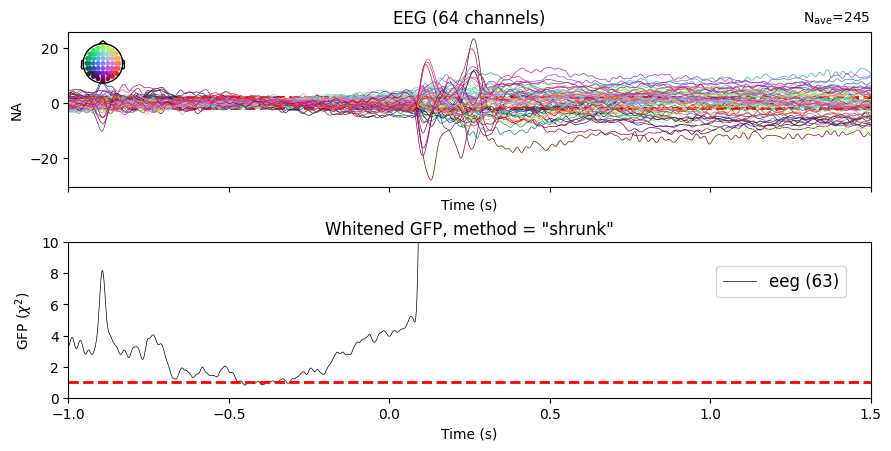

In [62]:
evoked.plot_white(noise_cov, time_unit='s')

In [63]:
inv = make_inverse_operator(evoked.info, fwd, noise_cov, loose=0.2, depth=0.8,
                            verbose=True)

Converting forward solution to surface orientation
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Computing inverse operator with 64 channels.
    64 out of 64 channels remain after picking
Selected 64 channels
Creating the depth weighting matrix...
    64 EEG channels
    limit = 20485/20484 = 2.329337
    scale = 108975 exp = 0.8
Applying loose dipole orientations to surface source spaces: 0.2
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 1)
Computing rank from covariance with rank=None
    Using tolerance 1e-13 (2.2e-16 eps * 64 dim * 7  max singular value)
    Estimated rank (eeg): 63
    EEG: rank 63 computed from 64 data channels with 1 projector
    Setting small EEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whit

In [64]:
%matplotlib qt
mne.viz.set_3d_backend("pyvistaqt")
snr = 3.0
lambda2 = 1.0 / snr ** 2
kwargs = dict(
              size=(600, 600), clim=dict(kind='percent', lims=[90, 95, 99]),
              smoothing_steps=7,hemi='split',
               views=['lat', 'med'],
              time_viewer=True, show_traces=True)

stc = apply_inverse(evoked, inv, lambda2, 'MNE', verbose=True) # 'MNE', 'dSPM', 'sLORETA', and 'eLORETA',

brain = stc.plot( **kwargs)
brain.add_text(0.1, 0.9, 'mne', 'title', font_size=14)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 245
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 63 (1 small eigenvalues omitted)
Applying inverse operator to "0.15 × stim/motiv/extr + 0.17 × stim/motiv/hard + 0.17 × stim/motiv/easy + 0.16 × stim/amotiv/extr + 0.18 × stim/amotiv/hard + 0.17 × stim/amotiv/easy"...
    Picked 64 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained   4.6% variance
    Combining the current components...
[done]
Using control points [3.53630182e-13 4.58428005e-13 6.90252619e-13]


In [58]:
import os
import numpy as np
import mne
from mne.minimum_norm import make_inverse_operator, apply_inverse
os.chdir("C:/Users/mfbpe/OneDrive/Cognitive_Science/class/EEG/codes/")
from eeg_function import drop_trials

os.chdir(root_derivatives)

event_id_stim = {
    'stim/motiv/extr': 11, 'stim/motiv/hard': 12, 'stim/motiv/easy': 13,
    'stim/amotiv/extr': 14, 'stim/amotiv/hard': 15, 'stim/amotiv/easy': 16,
}

snr = 3.0
lambda2 = 1.0 / snr ** 2
method = 'MNE'

conds = ['all', 'mot', 'amot', 'hard', 'easy']
stc_mag = {c: [] for c in conds}

for part in all_files_path[:20]:
    raw = mne.io.read_raw_fif(part, preload=True)
    events = mne.find_events(raw, shortest_event=1)

    raw.pick('eeg')

    raw.set_eeg_reference('average', projection=True)

    epochs = mne.Epochs(raw, events, event_id=event_id_stim,
                        tmin=-1, tmax=1.5, baseline=(-1, 0),
                        reject=None, preload=True)

    chs_index = [k for k, x in enumerate(epochs.info['ch_names']) if x in ['FCz', 'Pz', 'Fz', 'CPz']]
    epochs_comb = mne.channels.combine_channels(epochs, dict(Avg=chs_index))
    _, list_ti, _, _, _ = drop_trials(epochs_comb, do_mean=1, do_peak=1, do_slope=1,
                                      T1=-.3, T2=.5, chs='all')
    epochs.drop(np.asarray(list_ti) == 0)

    noise_cov = mne.compute_covariance(epochs, tmin=-1, tmax=-0,
                                       method='shrunk', rank=None)
    inv = make_inverse_operator(epochs.info, fwd, noise_cov,
                                loose=0.2, depth=0.8)
    epochs.crop(tmin=-0.1, tmax=0.7)
    evokeds = {
        'all':  epochs.average(),
        'mot':  epochs['motiv'].average(),
        'amot': epochs['amotiv'].average(),
        'hard': epochs['hard'].average(),
        'easy': epochs['easy'].average(),
    }
    for name, ev in evokeds.items():
        stc_mag[name].append(apply_inverse(ev, inv, lambda2, method))

# Magnitude contrasts per participant
stcs = {
    'all':          stc_mag['all'],
    'motiv-amotiv': [a - b for a, b in zip(stc_mag['mot'], stc_mag['amot'])],
    'hard-easy':    [a - b for a, b in zip(stc_mag['hard'], stc_mag['easy'])],
}

def grand_avg(lst):
    out = lst[0].copy()
    out.data = np.mean([s.data for s in lst], axis=0)
    return out

ga = {k: grand_avg(v) for k, v in stcs.items()}

Opening raw data file sub-1_raw.fif...
    Range : 0 ... 1927679 =      0.000 ...  3764.998 secs
Ready.
Reading 0 ... 1927679  =      0.000 ...  3764.998 secs...
Finding events on: Status
2016 events found on stim channel Status
Event IDs: [ 1  2  3  4  5  6 11 12 13 14 15 16 21 22 23 24 25 26 31 32 33 34 35 36
 41 42 43 44 45 46 51 52 53 54 55 56]
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Not setting metadata
336 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 336 events and 1281 original time points ...
0 bad epochs dropped
Not setting metadata
336 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Dropped 91 epochs: 4, 17, 22, 24, 26, 

In [91]:
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

windows = {
    'N2': (0.240, 0.290),
    'P3': (0.325, 0.375),
}

# Lists must contain the same participants in the same order.
counts = [len(stc_mag[c]) for c in ('mot', 'amot', 'hard', 'easy')]
if len(set(counts)) != 1 or counts[0] < 2:
    raise ValueError("Condition lists must have matching lengths and ≥2 participants.")

contrasts = {
    'motiv-amotiv': [
        a - b for a, b in zip(stc_mag['mot'], stc_mag['amot'])
    ],
    'hard-easy': [
        a - b for a, b in zip(stc_mag['hard'], stc_mag['easy'])
    ],
}

labels = [
    label for label in mne.read_labels_from_annot(
        subject='fsaverage',
        parc='aparc',
        hemi='both',
        subjects_dir=subjects_dir,
    )
    if 'unknown' not in label.name.lower()
]


def roi_mean(stc, label, tmin, tmax):
    mask = (stc.times >= tmin) & (stc.times <= tmax)
    if not mask.any():
        raise ValueError(f"No samples in window {tmin}–{tmax}.")

    data = stc.in_label(label).data
    return float(data[:, mask].mean()) if data.shape[0] else np.nan


# One value per participant / contrast / region / window.
rows = []

for contrast_name, estimates in contrasts.items():
    for participant, stc in enumerate(estimates, start=1):
        for label in labels:
            for window_name, (tmin, tmax) in windows.items():
                rows.append({
                    'participant': participant,
                    'contrast': contrast_name,
                    'roi': label.name,
                    'window': window_name,
                    'value': roi_mean(stc, label, tmin, tmax),
                })

roi_values = pd.DataFrame(rows)

# Two-sided one-sample t-tests; no multiple-comparison correction.
test_rows = []

for keys, group in roi_values.groupby(
    ['contrast', 'roi', 'window'], sort=False
):
    x = group['value'].to_numpy()
    x = x[np.isfinite(x)]
    if len(x) < 2:
        continue

    mean = x.mean()
    sd = x.std(ddof=1)
    margin = stats.t.ppf(0.975, df=len(x) - 1) * sd / np.sqrt(len(x))

    if sd > 0:
        test = stats.ttest_1samp(x, popmean=0.0)
        t, p, dz = float(test.statistic), float(test.pvalue), mean / sd
    else:
        t, p, dz = np.nan, np.nan, np.nan

    test_rows.append({
        'contrast': keys[0],
        'roi': keys[1],
        'window': keys[2],
        'n': len(x),
        'mean_difference': mean,
        'ci95_low': mean - margin,
        'ci95_high': mean + margin,
        't': t,
        'df': len(x) - 1,
        'p_uncorrected': p,
        'cohen_dz': dz,
    })

results = pd.DataFrame(test_rows)

results = results.sort_values('p_uncorrected').reset_index(drop=True)


print(results.to_string(index=False, float_format=lambda x: f'{x:.4g}'))

Reading labels from parcellation...
   read 35 labels from C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc.annot
    contrast                         roi window  n  mean_difference   ci95_low  ci95_high        t  df  p_uncorrected  cohen_dz
   hard-easy         parstriangularis-rh     N2 20       -2.552e-14 -4.388e-14 -7.159e-15   -2.909  19       0.008998   -0.6505
motiv-amotiv       posteriorcingulate-lh     P3 20        1.997e-14  3.025e-15  3.692e-14    2.467  19        0.02332    0.5515
motiv-amotiv         superiorparietal-rh     P3 20        3.309e-14  4.979e-15   6.12e-14    2.464  19        0.02346    0.5509
   hard-easy             temporalpole-lh     N2 20        3.618e-14  4.653e-15  6.771e-14    2.402  19         0.0267    0.5371
   hard-easy            supramarginal-lh     P3 20        4.607e-14  5.583e-15  8.656e-14    2.382  19        0.02785    0.5326
  

In [65]:
# Plot (lateral + medial, both hemispheres)
plot_kw = dict(subject='fsaverage', subjects_dir=subjects_dir, hemi='split', 

               views=['lat', 'med'], initial_time=0, time_viewer=True, show_traces=True, size=(1000, 600))



In [66]:
ga['all'].plot(clim=dict(kind='percent', lims=[80, 90, 99]),  **plot_kw)

Using control points [2.16923272e-13 2.63501606e-13 3.81593117e-13]


In [67]:
ga['motiv-amotiv'].plot(
                  colormap='mne', **plot_kw)

Using control points [7.82949065e-14 9.14647360e-14 2.04203227e-13]


In [68]:
ga['hard-easy'].plot(
                     **plot_kw)

Using control points [1.02224618e-13 1.18082225e-13 2.30555558e-13]


In [ ]:


windows = {'N2': (0.24, 0.29), 'P3': (0.325, 0.375)}

highlights = [
    ('parstriangularis-rh', '#008000'),
    ('posteriorcingulate-lh', '#E69500'),
    ('superiorparietal-rh', '#800080'),
]

labels = {
    label.name: label
    for label in mne.read_labels_from_annot(
        'fsaverage', parc='aparc', hemi='both',
        subjects_dir=subjects_dir
    )
}

for name in [ 'hard-easy']:
    for w, (t0, t1) in windows.items():
        stc = ga[name].copy().crop(t0, t1).mean()
        vmax = np.percentile(np.abs(stc.data), 99)
        brain = stc.plot(
            subject='fsaverage', subjects_dir=subjects_dir,
            hemi = 'split',
            views=['lat', 'med', 'dor'],
            clim=dict(kind='percent', lims=[80, 90, 99]),
            view_layout='vertical',
            size=(1100, 1000),        
            colormap='mne' if name == 'all' else 'mne',
            time_viewer=False, time_label=None,
            background='white'
        )

        brain.add_text(
            0.01, 0.95,
            f'{name} {int(t0 * 1000)}–{int(t1 * 1000)} ms',
            'title', font_size=12, color='k'
        )

        for i, (region, color) in enumerate(highlights):
            label = labels[region]
            brain.add_label(
                label, hemi=label.hemi,
                color=color, borders=6, alpha=1
            )
            brain.add_text(
                0.01, 0.88 - i * 0.06, region,
                f'roi_{i}', font_size=10, color=color
            )

        brain.save_image(f'src_{name}_{w}_outlined.png')
        # brain.close()

Reading labels from parcellation...
   read 35 labels from C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\mfbpe\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc.annot
posteriorcingulate-lh: -8.8416e-15
superiorparietal-rh: 1.5536e-15
posteriorcingulate-lh: -4.2142e-16
superiorparietal-rh: 3.8542e-14
